In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DB_PATH = PROJECT_ROOT / "data" / "ecommerce.db"

conn = sqlite3.connect(DB_PATH)

print("Connected Successfully!")

Connected Successfully!


In [3]:
def run_sql(query):
    return pd.read_sql(query, conn)

# Business SQL #1 – Monthly Revenue Trend

## Business Question
How has monthly revenue, order volume, and average order value changed over time?

In [4]:
query = """
SELECT

    strftime('%Y-%m', order_purchase_timestamp) AS order_month,

    ROUND(
        SUM(total_payment),
        2
    ) AS monthly_revenue,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(
        AVG(total_payment),
        2
    ) AS average_order_value

FROM vw_customer_orders

GROUP BY order_month

ORDER BY order_month;
"""

monthly_revenue = run_sql(query)

display(monthly_revenue)

,order_month,monthly_revenue,total_orders,average_order_value
0,2016-09,252.24,4,84.08
1,2016-10,59090.48,324,182.38
2,2016-12,19.62,1,19.62
3,2017-01,138488.04,800,173.11
4,2017-02,291908.01,1780,163.99
5,2017-03,449863.60,2682,167.73
6,2017-04,417788.03,2404,173.79
7,2017-05,592918.82,3700,160.25
8,2017-06,511276.38,3245,157.56
9,2017-07,592382.92,4026,147.14


In [5]:
print("Number of months:", len(monthly_revenue))
print("First month:", monthly_revenue.iloc[0]["order_month"])
print("Last month:", monthly_revenue.iloc[-1]["order_month"])

Number of months: 25
First month: 2016-09
Last month: 2018-10


In [6]:
monthly_revenue.describe()

,monthly_revenue,total_orders,average_order_value
count,2.500000e+01,25.000000,25.00000
mean,6.403549e+05,3977.640000,158.04520
std,4.316790e+05,2699.938516,41.38646
min,1.962000e+01,1.000000,19.62000
25%,2.919080e+05,1780.000000,154.84000
50%,6.743963e+05,4285.000000,160.82000
75%,1.023880e+06,6512.000000,168.36000
max,1.194883e+06,7544.000000,277.47000


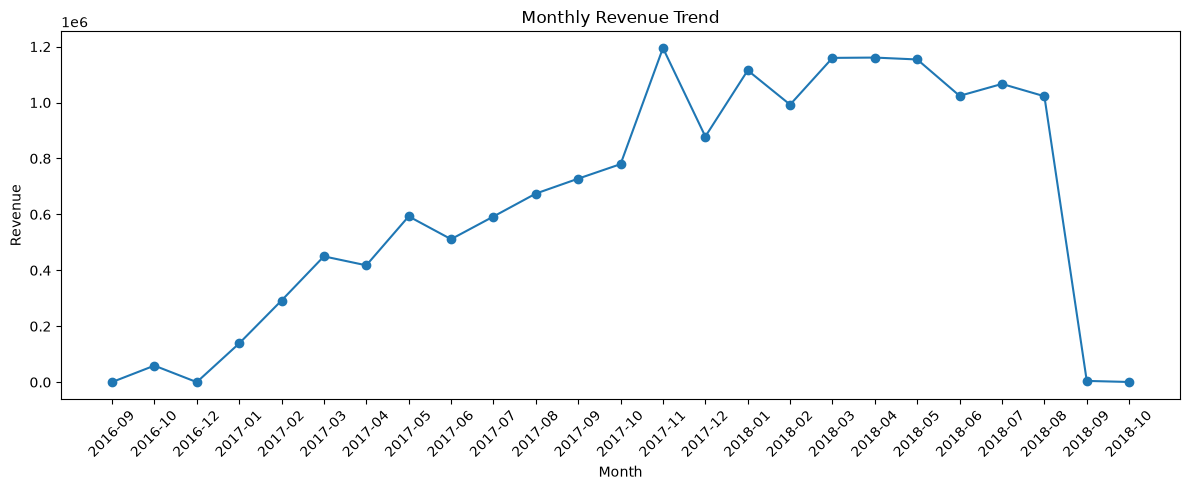

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["monthly_revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Business Interpretation

### Observations

- Revenue trend:
- Order trend:
- Average Order Value trend:

### Potential Business Drivers

(To be completed after Month-over-Month Growth analysis.)

# Business SQL #2 – Month-over-Month Revenue Growth

## Business Question
How quickly is revenue growing or declining each month?

In [8]:
query = """
WITH monthly_sales AS (

    SELECT

        strftime('%Y-%m', order_purchase_timestamp) AS order_month,

        SUM(total_payment) AS revenue

    FROM vw_customer_orders

    GROUP BY order_month

)

SELECT

    order_month,

    ROUND(revenue,2) AS revenue,

    ROUND(
        LAG(revenue) OVER (
            ORDER BY order_month
        ),
        2
    ) AS previous_month,

    ROUND(

        (
            revenue -
            LAG(revenue) OVER (
                ORDER BY order_month
            )
        )

        /

        LAG(revenue) OVER (
            ORDER BY order_month
        )

        *100,

        2

    ) AS mom_growth_pct

FROM monthly_sales;
"""

mom_growth = run_sql(query)

display(mom_growth)

,order_month,revenue,previous_month,mom_growth_pct
0,2016-09,252.24,NaN,NaN
1,2016-10,59090.48,252.24,23326.29
2,2016-12,19.62,59090.48,-99.97
3,2017-01,138488.04,19.62,705751.38
4,2017-02,291908.01,138488.04,110.78
5,2017-03,449863.60,291908.01,54.11
6,2017-04,417788.03,449863.60,-7.13
7,2017-05,592918.82,417788.03,41.92
8,2017-06,511276.38,592918.82,-13.77
9,2017-07,592382.92,511276.38,15.86


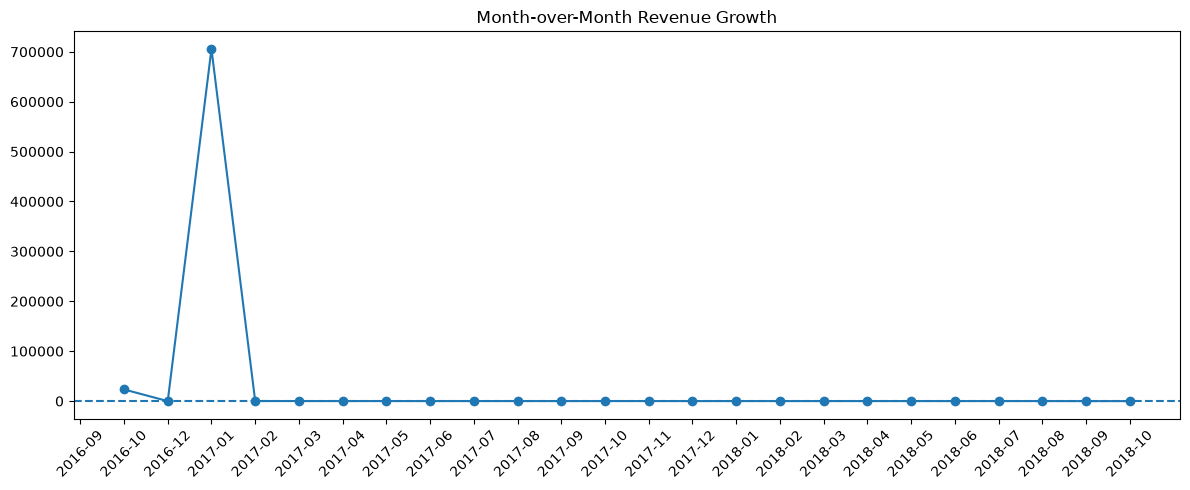

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    mom_growth["order_month"],
    mom_growth["mom_growth_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xticks(rotation=45)

plt.title("Month-over-Month Revenue Growth")

plt.tight_layout()

plt.show()

# Business SQL #3 – Category Performance Analysis

## Business Question

Which product categories generate the highest merchandise value?

In [12]:
query = """
SELECT

    category,

    COUNT(*) AS items_sold,

    ROUND(
        SUM(price),
        2
    ) AS merchandise_value,

    ROUND(
        AVG(price),
        2
    ) AS average_price,

    ROUND(
        SUM(freight_value),
        2
    ) AS total_freight,

    COUNT(DISTINCT order_id) AS unique_orders

FROM vw_product_sales

GROUP BY category

ORDER BY merchandise_value DESC;
"""

category_sales = run_sql(query)

display(category_sales)

,category,items_sold,merchandise_value,average_price,total_freight,unique_orders
0,health_beauty,9670,1258681.34,130.16,182566.73,8836
1,watches_gifts,5991,1205005.68,201.14,100535.93,5624
2,bed_bath_table,11115,1036988.68,93.30,204693.04,9417
3,sports_leisure,8641,988048.97,114.34,168607.51,7720
4,computers_accessories,7827,911954.32,116.51,147318.08,6689
...,...,...,...,...,...,...
69,flowers,33,1110.04,33.64,488.87,29
70,home_comfort_2,30,760.27,25.34,410.31,24
71,cds_dvds_musicals,14,730.00,52.14,224.99,12
72,fashion_childrens_clothes,8,569.85,71.23,95.51,8


In [13]:
print("Number of Categories:", len(category_sales))

category_sales.head(10)

Number of Categories: 74


,category,items_sold,merchandise_value,average_price,total_freight,unique_orders
0,health_beauty,9670,1258681.34,130.16,182566.73,8836
1,watches_gifts,5991,1205005.68,201.14,100535.93,5624
2,bed_bath_table,11115,1036988.68,93.30,204693.04,9417
3,sports_leisure,8641,988048.97,114.34,168607.51,7720
4,computers_accessories,7827,911954.32,116.51,147318.08,6689
5,furniture_decor,8334,729762.49,87.56,172749.30,6449
6,cool_stuff,3796,635290.85,167.36,84039.10,3632
7,housewares,6964,632248.66,90.79,146149.11,5884
8,auto,4235,592720.11,139.96,92664.21,3897
9,garden_tools,4347,485256.46,111.63,98962.75,3518


In [14]:
query = """
WITH category_summary AS (

    SELECT

        category,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY category

)

SELECT

    category,

    ROUND(revenue,2) AS revenue,

    ROUND(

        revenue
        *100.0
        /

        SUM(revenue)
        OVER(),

        2

    ) AS revenue_share_pct

FROM category_summary

ORDER BY revenue DESC;
"""

category_share = run_sql(query)

display(category_share)

,category,revenue,revenue_share_pct
0,health_beauty,1258681.34,9.26
1,watches_gifts,1205005.68,8.87
2,bed_bath_table,1036988.68,7.63
3,sports_leisure,988048.97,7.27
4,computers_accessories,911954.32,6.71
...,...,...,...
69,flowers,1110.04,0.01
70,home_comfort_2,760.27,0.01
71,cds_dvds_musicals,730.00,0.01
72,fashion_childrens_clothes,569.85,0.00


In [15]:
query = """
WITH category_summary AS (

    SELECT

        category,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY category

)

SELECT

    category,

    ROUND(revenue,2) AS revenue,

    ROUND(

        revenue
        *100.0

        /

        SUM(revenue)
        OVER(),

        2

    ) AS revenue_share,

    ROUND(

        SUM(revenue)
        OVER(

            ORDER BY revenue DESC

        )

        *100.0

        /

        SUM(revenue)
        OVER(),

        2

    ) AS cumulative_share

FROM category_summary

ORDER BY revenue DESC;
"""

pareto = run_sql(query)

display(pareto)

,category,revenue,revenue_share,cumulative_share
0,health_beauty,1258681.34,9.26,9.26
1,watches_gifts,1205005.68,8.87,18.13
2,bed_bath_table,1036988.68,7.63,25.76
3,sports_leisure,988048.97,7.27,33.03
4,computers_accessories,911954.32,6.71,39.74
...,...,...,...,...
69,flowers,1110.04,0.01,99.98
70,home_comfort_2,760.27,0.01,99.99
71,cds_dvds_musicals,730.00,0.01,99.99
72,fashion_childrens_clothes,569.85,0.00,100.00


In [16]:
query = """
WITH category_summary AS (

    SELECT

        category,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY category

)

SELECT

    RANK() OVER(
        ORDER BY revenue DESC
    ) AS revenue_rank,

    category,

    ROUND(revenue,2) AS revenue

FROM category_summary

ORDER BY revenue DESC;
"""

category_rank = run_sql(query)

display(category_rank)

,revenue_rank,category,revenue
0,1,health_beauty,1258681.34
1,2,watches_gifts,1205005.68
2,3,bed_bath_table,1036988.68
3,4,sports_leisure,988048.97
4,5,computers_accessories,911954.32
...,...,...,...
69,70,flowers,1110.04
70,71,home_comfort_2,760.27
71,72,cds_dvds_musicals,730.00
72,73,fashion_childrens_clothes,569.85


## Business Interpretation

### Key Findings

- Identify the highest revenue-generating product categories.
- Compare category contributions to overall merchandise value.
- Determine whether revenue is concentrated among a small number of categories (Pareto Principle).
- Prioritize top-performing categories for inventory planning, promotions, and marketing investment.

# Business SQL #4 – Top Products & ABC Analysis

## Business Question

Which individual products generate the highest merchandise value?

In [17]:
query = """
SELECT

    product_id,

    category,

    COUNT(*) AS units_sold,

    COUNT(DISTINCT order_id) AS unique_orders,

    ROUND(SUM(price),2) AS merchandise_value,

    ROUND(AVG(price),2) AS average_price

FROM vw_product_sales

GROUP BY

    product_id,
    category

ORDER BY merchandise_value DESC

LIMIT 20;
"""

top_products = run_sql(query)

display(top_products)

,product_id,category,units_sold,unique_orders,merchandise_value,average_price
0,bb50f2e236e5eea0100680137654686c,health_beauty,195,187,63885.00,327.62
1,6cdd53843498f92890544667809f1595,health_beauty,156,151,54730.20,350.83
2,d6160fb7873f184099d9bc95e30376af,computers,35,35,48899.34,1397.12
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,323,47214.51,137.65
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,467,43025.56,88.17
5,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,255,41082.60,149.94
6,25c38557cf793876c5abdd5931f922db,baby,38,38,38907.32,1023.88
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,63,37733.90,598.95
8,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,306,37683.42,116.67
9,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,431,37608.90,71.36


In [18]:
query = """
WITH product_summary AS (

    SELECT

        product_id,

        category,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY

        product_id,
        category

)

SELECT

    product_id,

    category,

    ROUND(revenue,2) AS revenue,

    ROUND(

        revenue * 100.0

        /

        SUM(revenue) OVER(),

        4

    ) AS revenue_share_pct

FROM product_summary

ORDER BY revenue DESC;
"""

product_share = run_sql(query)

display(product_share.head(20))

,product_id,category,revenue,revenue_share_pct
0,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00,0.4700
1,6cdd53843498f92890544667809f1595,health_beauty,54730.20,0.4027
2,d6160fb7873f184099d9bc95e30376af,computers,48899.34,0.3598
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51,0.3474
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56,0.3166
5,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,41082.60,0.3023
6,25c38557cf793876c5abdd5931f922db,baby,38907.32,0.2863
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,0.2776
8,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37683.42,0.2773
9,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37608.90,0.2767


In [19]:
query = """
WITH product_summary AS (

    SELECT

        product_id,

        category,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY

        product_id,
        category

),

product_pareto AS (

    SELECT

        product_id,

        category,

        revenue,

        SUM(revenue)
        OVER(

            ORDER BY revenue DESC

        ) * 1.0

        /

        SUM(revenue)
        OVER()

        AS cumulative_pct

    FROM product_summary

)

SELECT

    product_id,

    category,

    ROUND(revenue,2) AS revenue,

    ROUND(cumulative_pct*100,2) AS cumulative_pct,

    CASE

        WHEN cumulative_pct <= 0.80 THEN 'A'

        WHEN cumulative_pct <= 0.95 THEN 'B'

        ELSE 'C'

    END AS abc_class

FROM product_pareto

ORDER BY revenue DESC;
"""

abc_analysis = run_sql(query)

display(abc_analysis.head(30))

,product_id,category,revenue,cumulative_pct,abc_class
0,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00,0.47,A
1,6cdd53843498f92890544667809f1595,health_beauty,54730.20,0.87,A
2,d6160fb7873f184099d9bc95e30376af,computers,48899.34,1.23,A
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51,1.58,A
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56,1.90,A
5,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,41082.60,2.20,A
6,25c38557cf793876c5abdd5931f922db,baby,38907.32,2.48,A
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,2.76,A
8,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37683.42,3.04,A
9,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37608.90,3.32,A


In [20]:
query = """
WITH product_summary AS (

    SELECT

        product_id,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY product_id

),

product_pareto AS (

    SELECT

        product_id,

        revenue,

        SUM(revenue)
        OVER(

            ORDER BY revenue DESC

        ) * 1.0

        /

        SUM(revenue)
        OVER()

        AS cumulative_pct

    FROM product_summary

)

SELECT

CASE

    WHEN cumulative_pct <= 0.80 THEN 'A'

    WHEN cumulative_pct <= 0.95 THEN 'B'

    ELSE 'C'

END AS abc_class,

COUNT(*) AS products,

ROUND(SUM(revenue),2) AS merchandise_value

FROM product_pareto

GROUP BY abc_class

ORDER BY abc_class;
"""

abc_summary = run_sql(query)

display(abc_summary)

,abc_class,products,merchandise_value
0,A,8535,10873149.58
1,B,11257,2034483.20
2,C,13159,684010.92


## Business Interpretation

### Key Findings

- Identify the products contributing the highest merchandise value.
- Classify products into A, B, and C groups based on cumulative revenue contribution.
- Prioritize Class A products for inventory planning, demand forecasting, pricing strategy, and promotional investment.
- Manage Class C products with cost-efficient stocking strategies due to their relatively lower contribution.

# Business SQL #5 – Geographic Revenue Analysis

## Business Question

Which states generate the highest merchandise value?

In [21]:
query = """
SELECT

    customer_state,

    COUNT(DISTINCT order_id) AS total_orders,

    COUNT(DISTINCT customer_unique_id) AS unique_customers,

    ROUND(SUM(total_payment),2) AS revenue,

    ROUND(AVG(total_payment),2) AS average_order_value

FROM vw_customer_orders

GROUP BY customer_state

ORDER BY revenue DESC;
"""

state_revenue = run_sql(query)

display(state_revenue)

,customer_state,total_orders,unique_customers,revenue,average_order_value
0,SP,41746,40302,5998226.96,143.69
1,RJ,12852,12384,2144379.69,166.85
2,MG,11635,11259,1872257.26,160.92
3,RS,5466,5277,890898.54,162.99
4,PR,5045,4882,811156.38,160.78
5,SC,3637,3534,623086.43,171.32
6,BA,3380,3277,616645.82,182.44
7,DF,2140,2075,355141.08,165.95
8,GO,2020,1952,350092.31,173.31
9,ES,2033,1964,325967.55,160.34


In [22]:
query = """
WITH state_summary AS (

    SELECT

        customer_state,

        SUM(total_payment) AS revenue

    FROM vw_customer_orders

    GROUP BY customer_state

)

SELECT

    customer_state,

    ROUND(revenue,2) AS revenue,

    ROUND(

        revenue * 100.0

        /

        SUM(revenue) OVER(),

        2

    ) AS revenue_share_pct

FROM state_summary

ORDER BY revenue DESC;
"""

state_share = run_sql(query)

display(state_share)

,customer_state,revenue,revenue_share_pct
0,SP,5998226.96,37.47
1,RJ,2144379.69,13.39
2,MG,1872257.26,11.70
3,RS,890898.54,5.57
4,PR,811156.38,5.07
5,SC,623086.43,3.89
6,BA,616645.82,3.85
7,DF,355141.08,2.22
8,GO,350092.31,2.19
9,ES,325967.55,2.04


In [23]:
query = """
SELECT

    customer_state,

    COUNT(DISTINCT customer_unique_id) AS customers,

    ROUND(SUM(total_payment),2) AS revenue,

    ROUND(

        SUM(total_payment)

        /

        COUNT(DISTINCT customer_unique_id),

        2

    ) AS revenue_per_customer

FROM vw_customer_orders

GROUP BY customer_state

ORDER BY revenue_per_customer DESC;
"""

revenue_per_customer = run_sql(query)

display(revenue_per_customer)

,customer_state,customers,revenue,revenue_per_customer
0,PB,519,141545.72,272.73
1,AC,77,19680.62,255.59
2,RO,240,60866.20,253.61
3,AP,67,16262.80,242.73
4,AL,401,96962.06,241.80
5,PA,949,218295.85,230.03
6,TO,273,61485.33,225.22
7,PI,482,108523.97,225.15
8,RR,45,10064.62,223.66
9,SE,342,75246.25,220.02


In [24]:
display(state_revenue.head(10))

,customer_state,total_orders,unique_customers,revenue,average_order_value
0,SP,41746,40302,5998226.96,143.69
1,RJ,12852,12384,2144379.69,166.85
2,MG,11635,11259,1872257.26,160.92
3,RS,5466,5277,890898.54,162.99
4,PR,5045,4882,811156.38,160.78
5,SC,3637,3534,623086.43,171.32
6,BA,3380,3277,616645.82,182.44
7,DF,2140,2075,355141.08,165.95
8,GO,2020,1952,350092.31,173.31
9,ES,2033,1964,325967.55,160.34


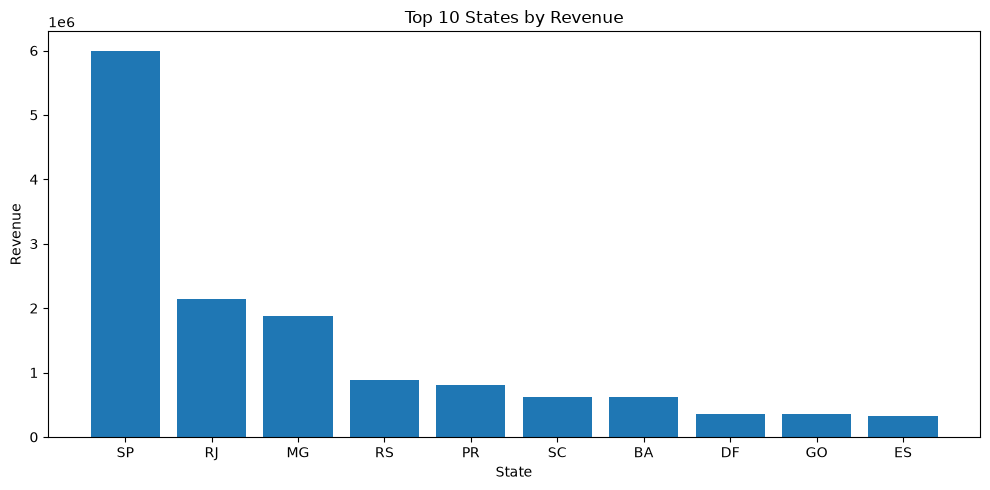

In [25]:
import matplotlib.pyplot as plt

top10 = state_revenue.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["customer_state"],
    top10["revenue"]
)

plt.title("Top 10 States by Revenue")

plt.xlabel("State")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Business Interpretation

### Key Findings

- Identify the highest revenue-generating states.
- Compare customer base with merchandise value.
- Evaluate revenue per customer to identify high-value regions.
- Highlight states with strong customer acquisition but relatively lower revenue per customer for targeted marketing and pricing strategies.

# Business SQL #6 – Seller Performance Analysis

## Business Question

Which sellers generate the highest merchandise value and process the most customer orders?

In [26]:
query = """
SELECT

    seller_id,

    COUNT(DISTINCT order_id) AS total_orders,

    COUNT(*) AS items_sold,

    ROUND(
        SUM(price),
        2
    ) AS merchandise_value,

    ROUND(
        SUM(freight_value),
        2
    ) AS freight_value,

    ROUND(
        AVG(price),
        2
    ) AS average_item_price

FROM vw_product_sales

GROUP BY seller_id

ORDER BY merchandise_value DESC;
"""

seller_performance = run_sql(query)

display(seller_performance)

,seller_id,total_orders,items_sold,merchandise_value,freight_value,average_item_price
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,20168.07,198.51
1,53243585a1d6dc2643021fd1853d8905,358,410,222776.05,13080.63,543.36
2,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,35067.04,100.89
3,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,10042.70,331.13
4,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,51612.55,137.77
...,...,...,...,...,...,...
3090,34aefe746cd81b7f3b23253ea28bef39,1,1,8.00,14.52,8.00
3091,702835e4b785b67a084280efca355756,1,1,7.60,10.96,7.60
3092,1fa2d3def6adfa70e58c276bb64fe5bb,1,1,6.90,9.00,6.90
3093,77128dec4bec4878c37ab7d6169d6f26,1,1,6.50,8.72,6.50


In [27]:
query = """
WITH seller_summary AS (

    SELECT

        seller_id,

        SUM(price) AS revenue

    FROM vw_product_sales

    GROUP BY seller_id

)

SELECT

    seller_id,

    ROUND(revenue,2) AS revenue,

    ROUND(

        revenue * 100.0

        /

        SUM(revenue) OVER(),

        2

    ) AS revenue_share_pct

FROM seller_summary

ORDER BY revenue DESC;
"""

seller_share = run_sql(query)

display(seller_share.head(20))

,seller_id,revenue,revenue_share_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1.69
1,53243585a1d6dc2643021fd1853d8905,222776.05,1.64
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1.47
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,1.43
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1.38
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,1.30
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1.18
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1.04
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1.02
9,955fee9216a65b617aa5c0531780ce60,135171.70,0.99


In [28]:
top10_sellers = seller_performance.head(10)

display(top10_sellers)

,seller_id,total_orders,items_sold,merchandise_value,freight_value,average_item_price
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,20168.07,198.51
1,53243585a1d6dc2643021fd1853d8905,358,410,222776.05,13080.63,543.36
2,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,35067.04,100.89
3,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,10042.70,331.13
4,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,51612.55,137.77
5,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,6322.18,518.92
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,24955.75,103.31
7,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,20902.85,121.05
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,33892.14,97.32
9,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,25430.98,90.17


In [29]:
query = """
SELECT

    seller_id,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(
        SUM(price),
        2
    ) AS merchandise_value,

    ROUND(

        SUM(price)

        /

        COUNT(DISTINCT order_id),

        2

    ) AS average_order_value

FROM vw_product_sales

GROUP BY seller_id

ORDER BY average_order_value DESC;
"""

seller_aov = run_sql(query)

display(seller_aov.head(20))

,seller_id,total_orders,merchandise_value,average_order_value
0,80ceebb4ee9b31afb6c6a916a574a1e2,1,6729.00,6729.00
1,ee27a8f15b1dded4d213a468ba4eb391,1,6499.00,6499.00
2,b37c4c02bda3161a7546a4e6d222d5b2,4,24075.00,6018.75
3,585175ec331ea177fa47199e39a6170a,1,3549.00,3549.00
4,abe021b01ba992245271b9aa422032df,2,6720.00,3360.00
5,a00824eb9093d40e589b940ec45c4eb0,3,9399.97,3133.32
6,e2a1ac9bf33e5549a2a4f834e70df2f8,5,14999.45,2999.89
7,e908c0f3646e8b60375734a350d95d71,1,2951.00,2951.00
8,d63c73efd41eb002280e7ec831424edb,2,5598.00,2799.00
9,1444c08e64d55fb3c25f0f09c07ffcf2,1,2749.00,2749.00


## Business Interpretation

### Key Findings

- Identify the highest-performing sellers by merchandise value.
- Compare seller revenue with order volume.
- Evaluate seller average order value to distinguish high-value sellers from high-volume sellers.
- Use seller performance metrics to support marketplace partnerships, promotions, and seller relationship management.

# Business SQL #7 – Delivery & Logistics Analytics

## Business Question

How efficiently are customer orders being delivered across the marketplace?

In [30]:
query = """
SELECT

    COUNT(*) AS delivered_orders,

    ROUND(
        AVG(
            JULIANDAY(order_delivered_customer_date)
            -
            JULIANDAY(order_purchase_timestamp)
        ),
        2
    ) AS avg_delivery_days,

    ROUND(
        AVG(
            JULIANDAY(order_estimated_delivery_date)
            -
            JULIANDAY(order_purchase_timestamp)
        ),
        2
    ) AS avg_estimated_days

FROM vw_orders

WHERE order_status='delivered'

AND order_delivered_customer_date IS NOT NULL;
"""

delivery_kpi = run_sql(query)

display(delivery_kpi)

,delivered_orders,avg_delivery_days,avg_estimated_days
0,96470,12.56,23.74


In [31]:
query = """
SELECT

    COUNT(*) AS delivered_orders,

    SUM(

        CASE

            WHEN order_delivered_customer_date
                 <= order_estimated_delivery_date

            THEN 1

            ELSE 0

        END

    ) AS on_time_orders,

    ROUND(

        100.0 *

        SUM(

            CASE

                WHEN order_delivered_customer_date
                     <= order_estimated_delivery_date

                THEN 1

                ELSE 0

            END

        )

        /

        COUNT(*),

        2

    ) AS on_time_percentage

FROM vw_orders

WHERE order_status='delivered'

AND order_delivered_customer_date IS NOT NULL;
"""

on_time = run_sql(query)

display(on_time)

,delivered_orders,on_time_orders,on_time_percentage
0,96470,88644,91.89


In [32]:
query = """
SELECT

    customer_state,

    COUNT(*) AS delivered_orders,

    ROUND(

        AVG(

            JULIANDAY(order_delivered_customer_date)

            -

            JULIANDAY(order_purchase_timestamp)

        ),

        2

    ) AS avg_delivery_days

FROM vw_orders

WHERE order_status='delivered'

AND order_delivered_customer_date IS NOT NULL

GROUP BY customer_state

ORDER BY avg_delivery_days DESC;
"""

state_delivery = run_sql(query)

display(state_delivery)

,customer_state,delivered_orders,avg_delivery_days
0,RR,41,29.39
1,AP,67,27.19
2,AM,145,26.43
3,AL,397,24.54
4,PA,946,23.77
5,MA,717,21.57
6,SE,335,21.52
7,CE,1279,21.27
8,AC,80,21.04
9,PB,517,20.43


In [33]:
query = """
SELECT

    customer_state,

    ROUND(

        AVG(freight_value),

        2

    ) AS avg_freight,

    ROUND(

        SUM(freight_value),

        2

    ) AS total_freight

FROM vw_product_sales

GROUP BY customer_state

ORDER BY avg_freight DESC;
"""

freight_state = run_sql(query)

display(freight_state)

,customer_state,avg_freight,total_freight
0,RR,42.98,2235.19
1,PB,42.72,25719.73
2,RO,41.07,11417.38
3,AC,40.07,3686.75
4,PI,39.15,21218.20
5,MA,38.26,31523.77
6,TO,37.25,11732.68
7,SE,36.65,14111.47
8,AL,35.84,15914.59
9,PA,35.83,38699.30


In [34]:
query = """
SELECT

    p.seller_id,

    COUNT(DISTINCT p.order_id) AS delivered_orders,

    ROUND(

        AVG(

            JULIANDAY(o.order_delivered_customer_date)

            -

            JULIANDAY(o.order_purchase_timestamp)

        ),

        2

    ) AS avg_delivery_days

FROM vw_product_sales p

JOIN vw_orders o

ON p.order_id = o.order_id

WHERE o.order_status='delivered'

AND o.order_delivered_customer_date IS NOT NULL

GROUP BY p.seller_id

HAVING COUNT(DISTINCT p.order_id) >= 20

ORDER BY avg_delivery_days DESC;
"""

seller_delivery = run_sql(query)

display(seller_delivery.head(20))

,seller_id,delivered_orders,avg_delivery_days
0,66e0557ecc2b4dbea057e93f215f68d8,30,31.73
1,054694fa03fe82cec4b7551487331d74,20,30.17
2,2a1348e9addc1af5aaa619b1a3679d6b,48,27.20
3,54965bbe3e4f07ae045b90b0b8541f52,73,26.73
4,5058e8c1e82653974541e83690655b4a,62,26.44
5,ad781527c93d00d89a11eecd9dcad7c1,38,25.50
6,712e6ed8aa4aa1fa65dab41fed5737e4,77,23.80
7,7f152321c60a266edc53af1925ef96c1,20,23.47
8,cee48807215b30a12ca2ca10ffb5f250,39,23.41
9,d93919c944be9cff128f6c9cb899eacb,33,22.92


## Business Interpretation

### Key Findings

- Measure the overall efficiency of the order fulfillment process.
- Identify the percentage of orders delivered on or before the estimated delivery date.
- Compare average delivery times across customer states to identify regions with slower logistics performance.
- Analyze freight costs by state to understand regional shipping expenses.
- Evaluate seller delivery performance to identify consistently slower or faster fulfillment partners.

# Business SQL #8 – Customer Experience Analytics

## Business Question

How satisfied are customers overall?

In [35]:
query = """
SELECT

    COUNT(*) AS total_reviews,

    ROUND(
        AVG(review_score),
        2
    ) AS average_rating,

    MIN(review_score) AS minimum_rating,

    MAX(review_score) AS maximum_rating

FROM reviews;
"""

review_summary = run_sql(query)

display(review_summary)

,total_reviews,average_rating,minimum_rating,maximum_rating
0,99224,4.09,1,5


In [36]:
query = """
SELECT

    review_score,

    COUNT(*) AS reviews,

    ROUND(

        COUNT(*) * 100.0

        /

        SUM(COUNT(*)) OVER(),

        2

    ) AS percentage

FROM reviews

GROUP BY review_score

ORDER BY review_score;
"""

rating_distribution = run_sql(query)

display(rating_distribution)

,review_score,reviews,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


In [37]:
query = """
SELECT

    review_score,

    ROUND(

        AVG(

            JULIANDAY(o.order_delivered_customer_date)

            -

            JULIANDAY(o.order_purchase_timestamp)

        ),

        2

    ) AS average_delivery_days,

    COUNT(*) AS total_reviews

FROM reviews r

JOIN orders o

ON r.order_id = o.order_id

WHERE o.order_status='delivered'

AND o.order_delivered_customer_date IS NOT NULL

GROUP BY review_score

ORDER BY review_score;
"""

delivery_review = run_sql(query)

display(delivery_review)

,review_score,average_delivery_days,total_reviews
0,1,21.31,9405
1,2,16.66,2941
2,3,14.26,7961
3,4,12.31,18987
4,5,10.69,57059


In [38]:
query = """
SELECT

    p.category,

    ROUND(

        AVG(r.review_score),

        2

    ) AS average_rating,

    COUNT(*) AS total_reviews

FROM reviews r

JOIN vw_product_sales p

ON r.order_id = p.order_id

GROUP BY p.category

HAVING COUNT(*) >= 50

ORDER BY average_rating DESC;
"""

category_reviews = run_sql(query)

display(category_reviews)

,category,average_rating,total_reviews
0,books_general_interest,4.45,549
1,costruction_tools_tools,4.44,99
2,books_imported,4.40,60
3,books_technical,4.37,266
4,luggage_accessories,4.32,1088
5,food_drink,4.32,279
6,small_appliances_home_oven_and_coffee,4.30,76
7,fashion_shoes,4.23,261
8,food,4.22,495
9,cine_photo,4.21,73


In [39]:
query = """
SELECT

    o.customer_state,

    ROUND(

        AVG(r.review_score),

        2

    ) AS average_rating,

    COUNT(*) AS reviews

FROM reviews r

JOIN vw_orders o

ON r.order_id = o.order_id

GROUP BY o.customer_state

HAVING COUNT(*) >= 100

ORDER BY average_rating DESC;
"""

state_reviews = run_sql(query)

display(state_reviews)

,customer_state,average_rating,reviews
0,PR,4.18,5038
1,AM,4.18,147
2,SP,4.17,41690
3,MG,4.14,11625
4,RS,4.13,5483
5,MS,4.12,724
6,RN,4.11,482
7,TO,4.10,279
8,MT,4.10,903
9,SC,4.07,3623


In [40]:
query = """
SELECT

    p.seller_id,

    ROUND(

        AVG(r.review_score),

        2

    ) AS average_rating,

    COUNT(DISTINCT r.order_id) AS reviewed_orders

FROM reviews r

JOIN vw_product_sales p

ON r.order_id = p.order_id

GROUP BY p.seller_id

HAVING COUNT(DISTINCT r.order_id) >= 20

ORDER BY average_rating DESC;
"""

seller_reviews = run_sql(query)

display(seller_reviews)

,seller_id,average_rating,reviewed_orders
0,48efc9d94a9834137efd9ea76b065a38,5.00,33
1,41c2bad7229b0c25e6becf179ebf63ff,4.96,20
2,02f5837340d7eb4f653d676c7256523a,4.83,30
3,d9bd94811c3338dceb4181f3dbc0c73e,4.82,54
4,d13e50eaa47b4cbe9eb81465865d8cfc,4.81,67
...,...,...,...
806,b19f3ca2ea475913750f25a5c37c8d8f,2.79,24
807,2eb70248d66e0e3ef83659f71b244378,2.71,198
808,2709af9587499e95e803a6498a5a56e9,2.57,25
809,1ca7077d890b907f89be8c954a02686a,2.20,114


## Business Interpretation

### Key Findings

- Measure overall customer satisfaction using review scores.
- Analyze the distribution of customer ratings to identify satisfaction trends.
- Evaluate the relationship between delivery performance and customer ratings.
- Identify high-performing and underperforming product categories based on customer feedback.
- Compare customer satisfaction across states to identify regional differences.
- Assess seller performance from the customer's perspective by analyzing average review scores.

# Business SQL #9 – Customer Lifetime Value (CLV)

## Business Question

Who are the highest-value customers based on total lifetime spending?

In [41]:
query = """
SELECT

    customer_unique_id,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(
        SUM(total_payment),
        2
    ) AS lifetime_value,

    ROUND(
        AVG(total_payment),
        2
    ) AS average_order_value

FROM vw_customer_orders

GROUP BY customer_unique_id

ORDER BY lifetime_value DESC

LIMIT 20;
"""

top_customers = run_sql(query)

display(top_customers)

,customer_unique_id,total_orders,lifetime_value,average_order_value
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.08
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.34
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.82
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.31
5,459bef486812aa25204be022145caa62,1,6922.21,6922.21
6,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.66
7,4007669dec559734d6f53e029e360987,1,6081.54,6081.54
8,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.44
9,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.34


In [42]:
query = """
SELECT

    ROUND(

        AVG(customer_revenue),

        2

    ) AS average_customer_lifetime_value

FROM (

    SELECT

        customer_unique_id,

        SUM(total_payment) AS customer_revenue

    FROM vw_customer_orders

    GROUP BY customer_unique_id

);
"""

average_clv = run_sql(query)

display(average_clv)

,average_customer_lifetime_value
0,166.59


In [43]:
query = """
SELECT

    total_orders,

    COUNT(*) AS customers,

    ROUND(

        COUNT(*) * 100.0

        /

        SUM(COUNT(*)) OVER(),

        2

    ) AS customer_percentage

FROM (

    SELECT

        customer_unique_id,

        COUNT(DISTINCT order_id) AS total_orders

    FROM vw_customer_orders

    GROUP BY customer_unique_id

)

GROUP BY total_orders

ORDER BY total_orders;
"""

purchase_frequency = run_sql(query)

display(purchase_frequency)

,total_orders,customers,customer_percentage
0,1,93099,96.88
1,2,2745,2.86
2,3,203,0.21
3,4,30,0.03
4,5,8,0.01
5,6,6,0.01
6,7,3,0.00
7,9,1,0.00
8,17,1,0.00


In [44]:
query = """
WITH customer_summary AS (

    SELECT

        customer_unique_id,

        COUNT(DISTINCT order_id) AS total_orders,

        SUM(total_payment) AS revenue

    FROM vw_customer_orders

    GROUP BY customer_unique_id

)

SELECT

    CASE

        WHEN total_orders = 1

        THEN 'One-Time'

        ELSE 'Repeat'

    END AS customer_type,

    COUNT(*) AS customers,

    ROUND(

        SUM(revenue),

        2

    ) AS total_revenue,

    ROUND(

        AVG(revenue),

        2

    ) AS average_customer_value

FROM customer_summary

GROUP BY customer_type;
"""

repeat_analysis = run_sql(query)

display(repeat_analysis)

,customer_type,customers,total_revenue,average_customer_value
0,One-Time,93099,15064849.41,161.82
1,Repeat,2997,944022.71,314.99


In [45]:
query = """
SELECT

    strftime('%Y-%m', MIN(order_purchase_timestamp)) AS acquisition_month,

    COUNT(*) AS new_customers

FROM vw_customer_orders

GROUP BY customer_unique_id

ORDER BY acquisition_month;
"""

customer_acquisition = run_sql(query)

display(customer_acquisition)

,acquisition_month,new_customers
0,2016-09,1
1,2016-09,1
2,2016-09,1
3,2016-09,1
4,2016-10,1
...,...,...
96091,2018-09,1
96092,2018-09,1
96093,2018-09,1
96094,2018-09,1


## Business Interpretation

### Key Findings

- Identify the highest-value customers based on lifetime spending.
- Calculate the average customer lifetime value across the marketplace.
- Analyze customer purchase frequency to understand repeat buying behavior.
- Compare revenue generated by repeat and one-time customers.
- Monitor monthly customer acquisition trends to evaluate business growth.

# Business SQL #10 – Executive Dashboard KPIs

## Business Question

What are the overall business performance metrics for the marketplace?

In [46]:
query = """
SELECT

    ROUND(SUM(total_payment),2) AS total_revenue,

    COUNT(DISTINCT order_id) AS total_orders,

    COUNT(DISTINCT customer_unique_id) AS total_customers,

    ROUND(

        AVG(total_payment),

        2

    ) AS average_order_value,

    ROUND(

        SUM(total_payment)

        /

        COUNT(DISTINCT customer_unique_id),

        2

    ) AS revenue_per_customer

FROM vw_customer_orders;
"""

executive_kpis = run_sql(query)

display(executive_kpis)

,total_revenue,total_orders,total_customers,average_order_value,revenue_per_customer
0,16008872.12,99441,96096,160.99,166.59


In [47]:
query = """
SELECT

    strftime('%Y-%m',order_purchase_timestamp) AS month,

    ROUND(SUM(total_payment),2) AS revenue,

    COUNT(DISTINCT order_id) AS orders,

    COUNT(DISTINCT customer_unique_id) AS customers,

    ROUND(

        AVG(total_payment),

        2

    ) AS average_order_value

FROM vw_customer_orders

GROUP BY month

ORDER BY month;
"""

monthly_summary = run_sql(query)

display(monthly_summary)

,month,revenue,orders,customers,average_order_value
0,2016-09,252.24,4,4,84.08
1,2016-10,59090.48,324,321,182.38
2,2016-12,19.62,1,1,19.62
3,2017-01,138488.04,800,765,173.11
4,2017-02,291908.01,1780,1755,163.99
5,2017-03,449863.60,2682,2642,167.73
6,2017-04,417788.03,2404,2372,173.79
7,2017-05,592918.82,3700,3625,160.25
8,2017-06,511276.38,3245,3180,157.56
9,2017-07,592382.92,4026,3947,147.14


In [48]:
query = """
SELECT

    p.order_id,

    o.order_purchase_timestamp,

    o.customer_state,

    o.customer_unique_id,

    p.seller_id,

    p.product_id,

    p.category,

    p.price,

    p.freight_value,

    p.gross_value,

    c.total_payment,

    o.order_status,

    o.order_delivered_customer_date,

    o.order_estimated_delivery_date

FROM vw_product_sales p

JOIN vw_orders o

ON p.order_id=o.order_id

JOIN vw_customer_orders c

ON p.order_id=c.order_id;
"""

dashboard_fact = run_sql(query)

display(dashboard_fact.head())

,order_id,order_purchase_timestamp,customer_state,customer_unique_id,seller_id,product_id,category,price,freight_value,gross_value,total_payment,order_status,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,7c396fd4830fd04220f754e42b4e5bff,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,housewares,29.99,8.72,38.71,38.71,delivered,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,BA,af07308b275d755c9edb36a90c618231,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,perfumery,118.70,22.76,141.46,141.46,delivered,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,GO,3a653a41f6f9fc3d2a113cf8398680e8,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,auto,159.90,19.22,179.12,179.12,delivered,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,RN,7c142cf63193a1473d2e66489a9ae977,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20,72.20,72.20,delivered,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,SP,72632f0f9dd73dfee390c9b22eb56dd6,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,stationery,19.90,8.72,28.62,28.62,delivered,2018-02-16 18:17:02,2018-02-26 00:00:00


## Business Interpretation

### Key Findings

- Provide a single source of truth for executive reporting.
- Consolidate customer, seller, product, payment, and logistics information into one analytical dataset.
- Enable Power BI to build dashboards without repeatedly joining multiple tables.
- Improve dashboard performance by reducing data transformation inside Power BI.